# PBMRS Demo Notebook

This notebook prints numeric values from a short PBMRS-style simulation and plots the resulting series.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd()
if (repo_root / "src").exists():
    sys.path.insert(0, str(repo_root / "src"))

from pbmrs_core import SimConfig, run_sim


In [ ]:
# Run a full PBMRS simulation directly inside the notebook.
cfg = SimConfig(seed=7, timesteps=200, n_agents=300, q0=0.008)
result = run_sim(cfg)

prices = result.prices
returns = result.r
volatility = result.v
liquidity = result.l

print("Simulation configuration:")
print(f"  seed={cfg.seed}")
print(f"  timesteps={cfg.timesteps}")
print(f"  n_agents={cfg.n_agents}")
print(f"  q0={cfg.q0}")
print()
print("Summary metrics:")
print(f"  final_price={prices[-1]:.6f}")
print(f"  max_drawdown={np.max(1.0 - prices / np.maximum.accumulate(prices)):0.6f}")
print(f"  mean_return={np.mean(returns):.6f}")
print(f"  return_std={np.std(returns):.6f}")
print(f"  min_liquidity={np.min(liquidity):.6f}")
print(f"  max_volatility={np.max(volatility):.6f}")
print()
print("First 10 price values:")
print(prices[:10])
print("\nFirst 10 return values:")
print(returns[:10])
print("\nFirst 10 volatility values:")
print(volatility[:10])
print("\nFirst 10 liquidity values:")
print(liquidity[:10])


Price path values:
[1.         0.99828739 1.00294731 0.97328686 1.00666153 1.023223
 1.02509246 1.0328923  1.05769267 1.03203448]

Return values:
[-0.00171407  0.00465705 -0.0300194   0.03371586  0.01631801  0.00182536
  0.00758011  0.02372689 -0.02455774 -0.00941165]

Volatility values:
[1.         1.0004633  1.00048737 1.00125779 1.00254834 1.00303446
 1.00288557 1.00333093 1.00396291 1.00430618]

Liquidity values:
[1.         0.99712    0.9964725  0.99584371 0.99329066 0.99077549
 0.99096119 0.98802579 0.98588509 0.98546965]


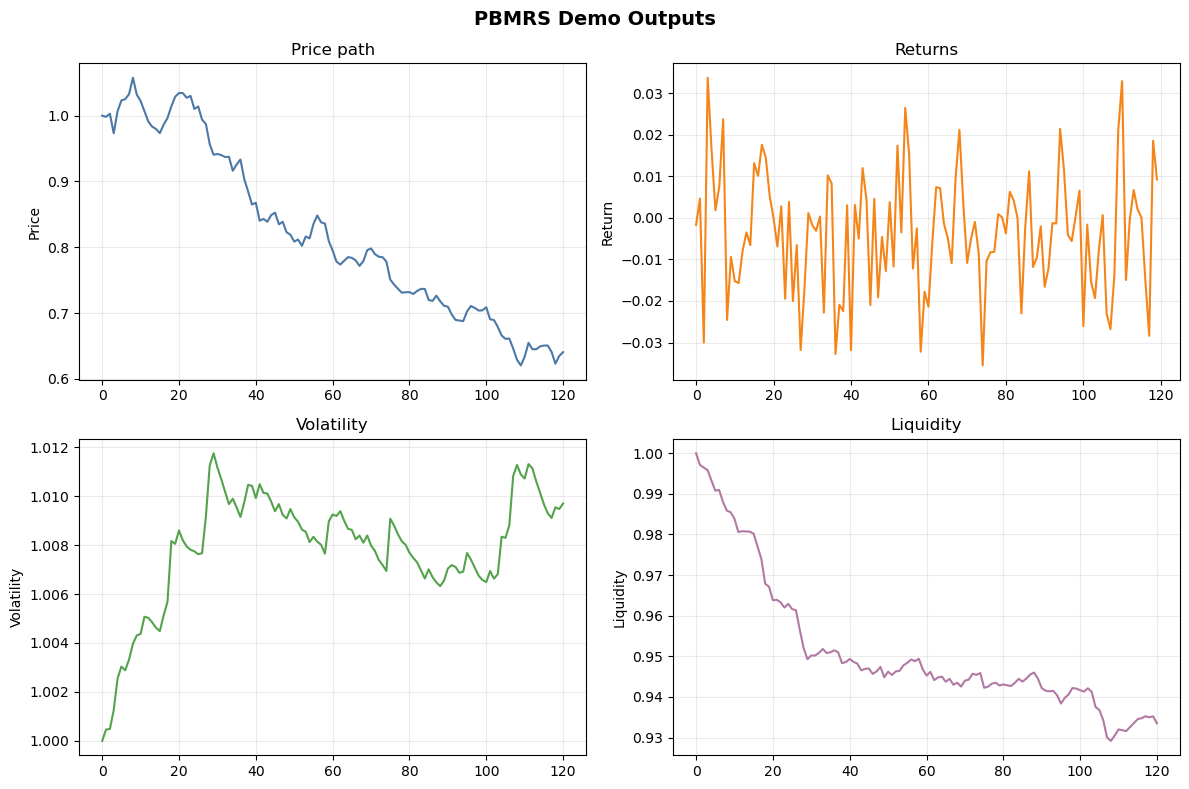

In [3]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("PBMRS Demo Outputs", fontsize=14, fontweight="bold")

axs[0, 0].plot(prices, color="#4C78A8")
axs[0, 0].set_title("Price path")
axs[0, 0].set_ylabel("Price")

axs[0, 1].plot(returns, color="#F58518")
axs[0, 1].set_title("Returns")
axs[0, 1].set_ylabel("Return")

axs[1, 0].plot(volatility, color="#54A24B")
axs[1, 0].set_title("Volatility")
axs[1, 0].set_ylabel("Volatility")

axs[1, 1].plot(liquidity, color="#B279A2")
axs[1, 1].set_title("Liquidity")
axs[1, 1].set_ylabel("Liquidity")

for ax in axs.flat:
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [4]:
output_path = Path("results") / "pbmrs_demo_notebook_values.txt"
output_path.parent.mkdir(exist_ok=True)

with output_path.open("w", encoding="utf-8") as handle:
    handle.write("Price path values\n")
    handle.write("\n".join(map(str, prices)) + "\n")
    handle.write("\nReturn values\n")
    handle.write("\n".join(map(str, returns)) + "\n")

print(f"Saved numeric values to {output_path}")


Saved numeric values to results\pbmrs_demo_notebook_values.txt
